In [1]:
import numpy as np 
import pandas as pd 
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("Mall_Customers.csv")
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [3]:
X=df[['Age','Annual Income (k$)','Spending Score (1-100)']]
# X=df.drop(columns=["CustomerID","Genre"])

The following are methods for calculating the distance between the newly formed cluster : math: `u` and each :math : `v`.

1. **Method = `single`** assigns
    .. math:: d(u,v) = \min(dist(u[i],v[j]))
    for all points :math:i in cluster :math:u and :math:j in cluster :math:v. This is also known as the Nearest Point Algorithm.

2. **Method= `complete`** assigns
    .. math:: d(u, v) = \max(dist(u[i],v[j]))
    for all points :math:`i` in cluster u and :math:`j` in cluster :math:`v`. This is also known by the Farthest Point Algorithm or Voor Hees Algorithm.

3. **Method= `average`** assigns
    .. math:: d(u,v) = \sum_{ij} \frac{d(u[i], v[j])}
                                       {(|u|*|v|)}
    for all points :math:`i` and :math:`j` where :math:`u`and :math:`v` are the cardinalities of clusters :math:`u`and :math:`v`, respectively. This is       also called the UPGMA algorithm.

4. **Method= `weighted`** assigns
    .. math:: d(u,v) = (dist(s,v) + dist(t,v))/2
    where cluster u was formed with cluster `s` and `t` and `v` is a remaining cluster in the forest (also called WPGMA).

5. **Method= `centroid`** assigns
    .. math:: dist(s,t) = ||c_s-c_t||_2
    where :math: `c_s` and :math: `c_t` are the centroids of clusters: math: `s` and :math: `t`, respectively. When two clusters :math: `s` and :math:        `t` are combined into a new cluster :math: `u`, the new centroid is computed over all the original objects in clusters :math: `s` and :math: `t`. The     distance then becomes the Euclidean distance between the centroid of :math: `u` and the centroid of a remaining cluster :math: `v` in the forest.         this is also known as the UPGMC algorithm.

6. **Method= `Median`** assigns :math: `d(s,t)` like the centroid method. When two clusters :math: `s` and :math: `t` are combined into a new cluster         :math: `u`, the average of centroids `s` and `t` give the new centroid :math: `u`. This is also known as the WPGMC algorithm.

7. **Method= `ward`** uses the Ward variance minimization algorithm. The new entry :math: `d(u,v)` is computed as follows,
   .. math:: d(u,v) = \sqrt{\frac{|v|+|s|} {T}d(v,s)^2 + \frac{|v|+|t|} {T}d(v,t)^2 - \frac{|v|} {T}d(s,t)^2}

# Case :1

In [5]:
import scipy.cluster.hierarchy as sh
link_data=sh.linkage(X,method='ward')

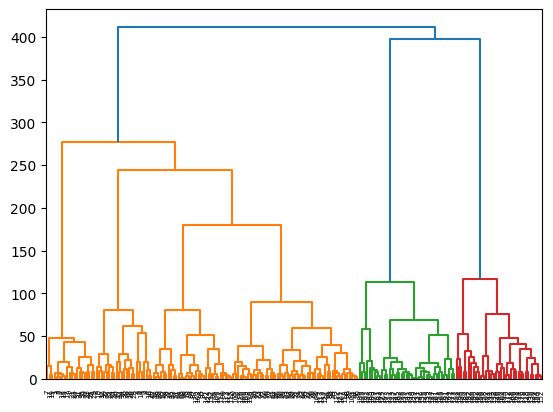

In [6]:
dendo=sh.dendrogram(link_data)

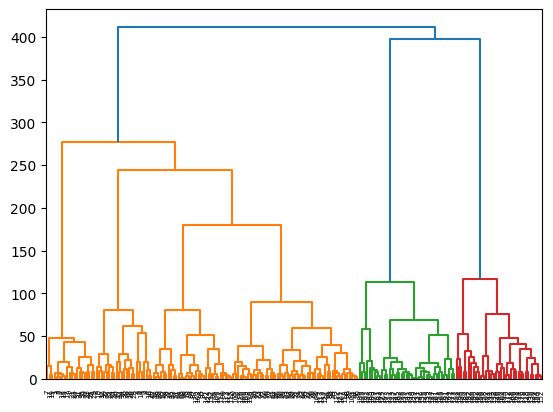

In [7]:
dendo=sh.dendrogram(sh.linkage(df[['Age','Annual Income (k$)','Spending Score (1-100)',]],method='ward'))

In [8]:
from sklearn.cluster import AgglomerativeClustering ,KMeans

In [9]:
# cluster= AgglomerativeClustering(n_clusters=5,affinity='euclidean',linkage='ward')
cluster= AgglomerativeClustering(n_clusters=5,metric='euclidean',linkage='ward')

In [10]:
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [11]:
X=df.drop(columns=['CustomerID','Genre'])

In [13]:
labels=cluster.fit_predict(X)
labels

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 0, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 0,
       4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 1, 2, 1, 2, 1, 2,
       0, 2, 1, 2, 1, 2, 1, 2, 1, 2, 0, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2])

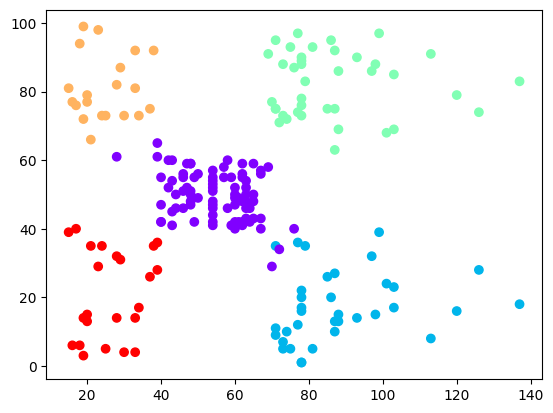

In [14]:
plt.scatter(df['Annual Income (k$)'],df['Spending Score (1-100)'],c=cluster.labels_,cmap="rainbow")
# plt.scatter(cluster.cluster_centers_[:, 0], cluster.cluster_centers_[:, 1],c = 'black', label ='Centroids')

In [ ]:
# x= df[['Annual Income (k$)','Spending Score (1-100)']]

In [ ]:
# x[cluster.labels_==4]

In [15]:
# Calculate Silhouette Scores
from sklearn.metrics import silhouette_score
agglo_silhouette = silhouette_score(X, labels)
agglo_silhouette

0.4401889024290193

# Case : 2

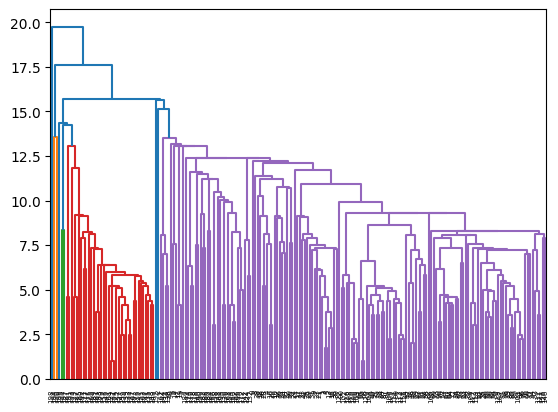

In [16]:
import scipy.cluster.hierarchy as sh
link_data=sh.linkage(X,method='single')
dendo=sh.dendrogram(link_data)

In [23]:
from sklearn.cluster import AgglomerativeClustering
cluster2= AgglomerativeClustering(n_clusters=5,metric='euclidean',linkage='single')

In [18]:
X=df.drop(columns=['CustomerID','Genre'])
label_2=cluster2.fit_predict(X)

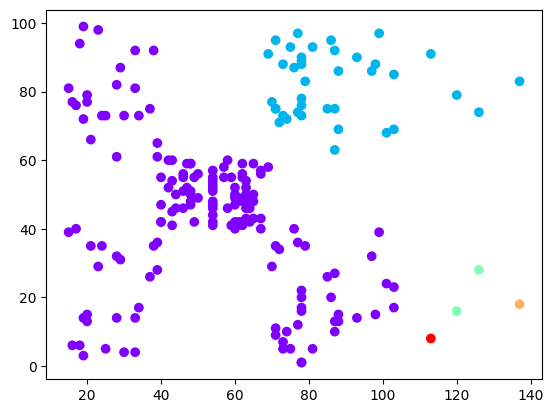

In [19]:
plt.scatter(df['Annual Income (k$)'],df['Spending Score (1-100)'],c=cluster2.labels_,cmap="rainbow")

In [20]:
# Calculate Silhouette Scores
from sklearn.metrics import silhouette_score
agglo_silhouette = silhouette_score(X, label_2)
agglo_silhouette

0.24294247504120228

# Case: 3

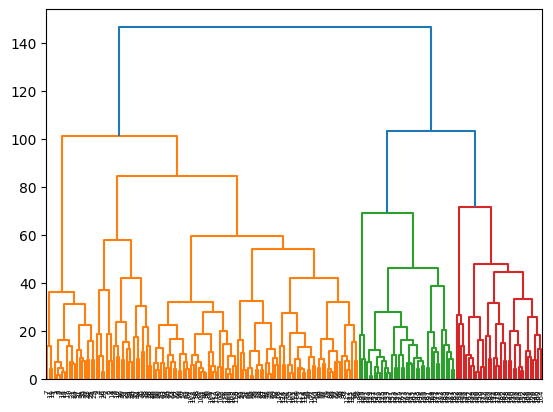

In [21]:
import scipy.cluster.hierarchy as sh
link_data=sh.linkage(X,method='complete')
dendo=sh.dendrogram(link_data)

In [31]:
from sklearn.cluster import AgglomerativeClustering
cluster3= AgglomerativeClustering(n_clusters=5,metric='euclidean',linkage='complete')

In [32]:
X=df.drop(columns=['CustomerID','Genre'])
label_3=cluster3.fit_predict(X)

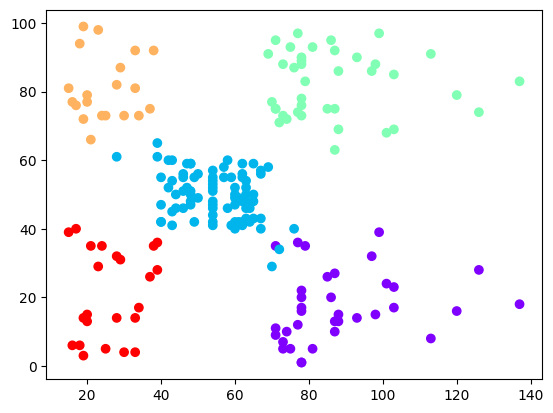

In [26]:
plt.scatter(df['Annual Income (k$)'],df['Spending Score (1-100)'],c=cluster3.labels_,cmap="rainbow")

In [27]:
# Calculate Silhouette Scores
from sklearn.metrics import silhouette_score
agglo_silhouette = silhouette_score(X, label_3)
agglo_silhouette

0.4401889024290193

# Case: 3

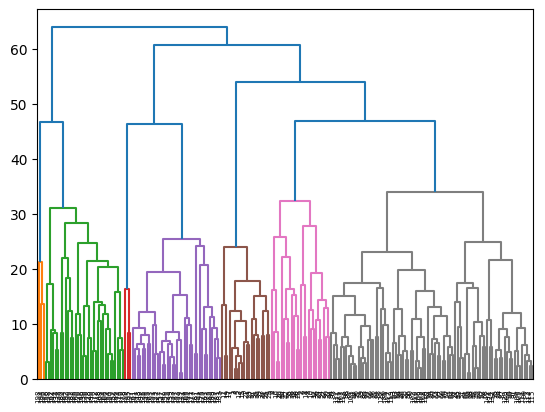

In [28]:
import scipy.cluster.hierarchy as sh
link_data=sh.linkage(X,method='average')
dendo=sh.dendrogram(link_data)

In [33]:
from sklearn.cluster import AgglomerativeClustering
cluster4= AgglomerativeClustering(n_clusters=5,metric='euclidean',linkage='average')

In [34]:
X=df.drop(columns=['CustomerID','Genre'])
label_4=cluster4.fit_predict(X)

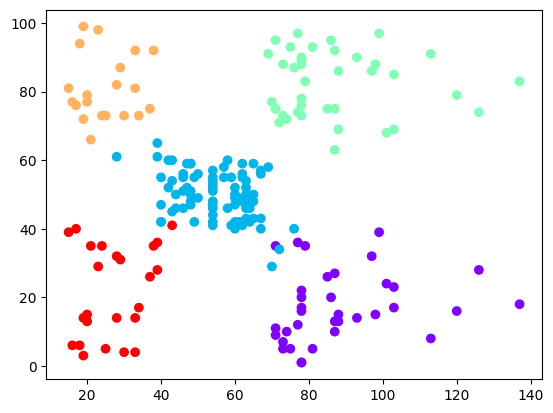

In [35]:
plt.scatter(df['Annual Income (k$)'],df['Spending Score (1-100)'],c=cluster4.labels_,cmap="rainbow")

In [36]:
# Calculate Silhouette Scores
from sklearn.metrics import silhouette_score
agglo_silhouette = silhouette_score(X, label_4)
agglo_silhouette

0.43542057757306424